# Human-Likeness Preference Evaluation

NeurIPS-style plots for the new Qwen vs frontier-model preference results. The notebook reads the generated CSVs directly, writes figure-ready PNG/PDF files, and displays the exact summary tables used for plotting.

In [1]:
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

RESULT_BASE_REL = Path("eval/results/humanlike_preference")
RESULT_RELS = {
    "decimal": RESULT_BASE_REL / "qwen_frontier3_gemini31_flash_lite_decimals_new" / "decimal",
    "fraction": RESULT_BASE_REL / "qwen_frontier3_4b_gemini31_flash_lite" / "fraction",
}
FIG_REL = RESULT_BASE_REL / "qwen_frontier3_4b_gemini31_flash_lite" / "figures"


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if all((candidate / rel).exists() for rel in RESULT_RELS.values()):
            return candidate
    expected = ", ".join(str(rel) for rel in RESULT_RELS.values())
    raise FileNotFoundError(f"Could not find {expected} from {Path.cwd()}")


ROOT = find_repo_root()
RESULT_DIRS = {domain: ROOT / rel for domain, rel in RESULT_RELS.items()}
FIG_DIR = ROOT / FIG_REL
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 10,
        "ytick.labelsize": 11,
        "legend.fontsize": 10.5,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

LABELS = {
    "qwen3_4b_distill_humanft": "Qwen3-4B",
    "qwen3_4b_distill_humanft_reasoning": "Qwen3-4B reasoning",
    "qwen3_8b_distill_humanft": "Qwen3-8B",
    "claude_sonnet_4_6": "Claude Sonnet 4.6",
    "gemini_3_flash": "Gemini 3 Flash",
    "gpt_5_5_low": "GPT-5.5 low",
}

DOMAIN_META = {
    "decimal": {
        "title": "Decimal",
        "anchor_label": "Qwen3-4B\nreasoning",
        "color": "#4C78A8",
    },
    "fraction": {
        "title": "Fraction",
        "anchor_label": "Qwen3-4B",
        "color": "#D55E00",
    },
}

MODEL_ORDER = ["claude_sonnet_4_6", "gemini_3_flash", "gpt_5_5_low"]
MODEL_COLOR = "#C7C7C7"
TIE_COLOR = "#F2F2F2"
EDGE_COLOR = "#333333"

print(f"Root: {ROOT}")
print("Results:")
for domain, path in RESULT_DIRS.items():
    print(f"  {domain}: {path}")
print(f"Figures: {FIG_DIR}")

Root: /scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share
Results:
  decimal: /scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_gemini31_flash_lite_decimals_new/decimal
  fraction: /scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/fraction
Figures: /scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures


## Load Preference Results

In [2]:
def load_summary(domain: str) -> pd.DataFrame:
    path = RESULT_DIRS[domain] / "preference_summary.csv"
    data = pd.read_csv(path)
    data["domain"] = domain
    data["domain_label"] = DOMAIN_META[domain]["title"]
    data["qwen_label"] = data["qwen_entity"].map(LABELS)
    data["baseline_label"] = data["baseline_entity"].map(LABELS)
    data["qwen_pct"] = 100.0 * data["qwen_preference_rate"]
    data["baseline_pct"] = 100.0 * data["baseline_preference_rate"]
    data["tie_pct"] = 100.0 * data["tie_rate"]
    data["baseline_order"] = data["baseline_entity"].map({name: i for i, name in enumerate(MODEL_ORDER)})
    return data.sort_values(["baseline_order"]).reset_index(drop=True)


def load_by_problem(domain: str) -> pd.DataFrame:
    path = RESULT_DIRS[domain] / "preference_by_problem.csv"
    data = pd.read_csv(path)
    data["domain"] = domain
    data["domain_label"] = DOMAIN_META[domain]["title"]
    data["baseline_label"] = data["baseline_entity"].map(LABELS)
    data["qwen_pct"] = 100.0 * data["qwen_preference_rate"]
    data["baseline_pct"] = 100.0 * data["baseline_preference_rate"]
    data["tie_pct"] = 100.0 * data["tie_rate"]
    data["baseline_order"] = data["baseline_entity"].map({name: i for i, name in enumerate(MODEL_ORDER)})
    return data.sort_values(["baseline_order", "prob"]).reset_index(drop=True)


summary = pd.concat([load_summary("decimal"), load_summary("fraction")], ignore_index=True)
by_problem = pd.concat([load_by_problem("decimal"), load_by_problem("fraction")], ignore_index=True)

display(
    summary[
        [
            "domain_label",
            "qwen_label",
            "baseline_label",
            "rows",
            "parse_success_rate",
            "qwen_pct",
            "baseline_pct",
            "tie_pct",
        ]
    ].round({"parse_success_rate": 3, "qwen_pct": 1, "baseline_pct": 1, "tie_pct": 1})
)

,domain_label,qwen_label,baseline_label,rows,parse_success_rate,qwen_pct,baseline_pct,tie_pct
0,Decimal,Qwen3-4B reasoning,Claude Sonnet 4.6,1200,1.0,36.5,63.5,0.0
1,Decimal,Qwen3-4B reasoning,Gemini 3 Flash,1200,1.0,58.9,41.1,0.0
2,Decimal,Qwen3-4B reasoning,GPT-5.5 low,1200,1.0,64.7,35.3,0.0
3,Fraction,Qwen3-4B,Claude Sonnet 4.6,1600,1.0,64.9,35.1,0.0
4,Fraction,Qwen3-4B,Gemini 3 Flash,1600,1.0,57.4,42.6,0.0
5,Fraction,Qwen3-4B,GPT-5.5 low,1600,1.0,61.4,38.6,0.0


## Main Preference Bars

/scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures/qwen_frontier3_4b_humanlike_preference_bars.png
/scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures/qwen_frontier3_4b_humanlike_preference_bars.pdf


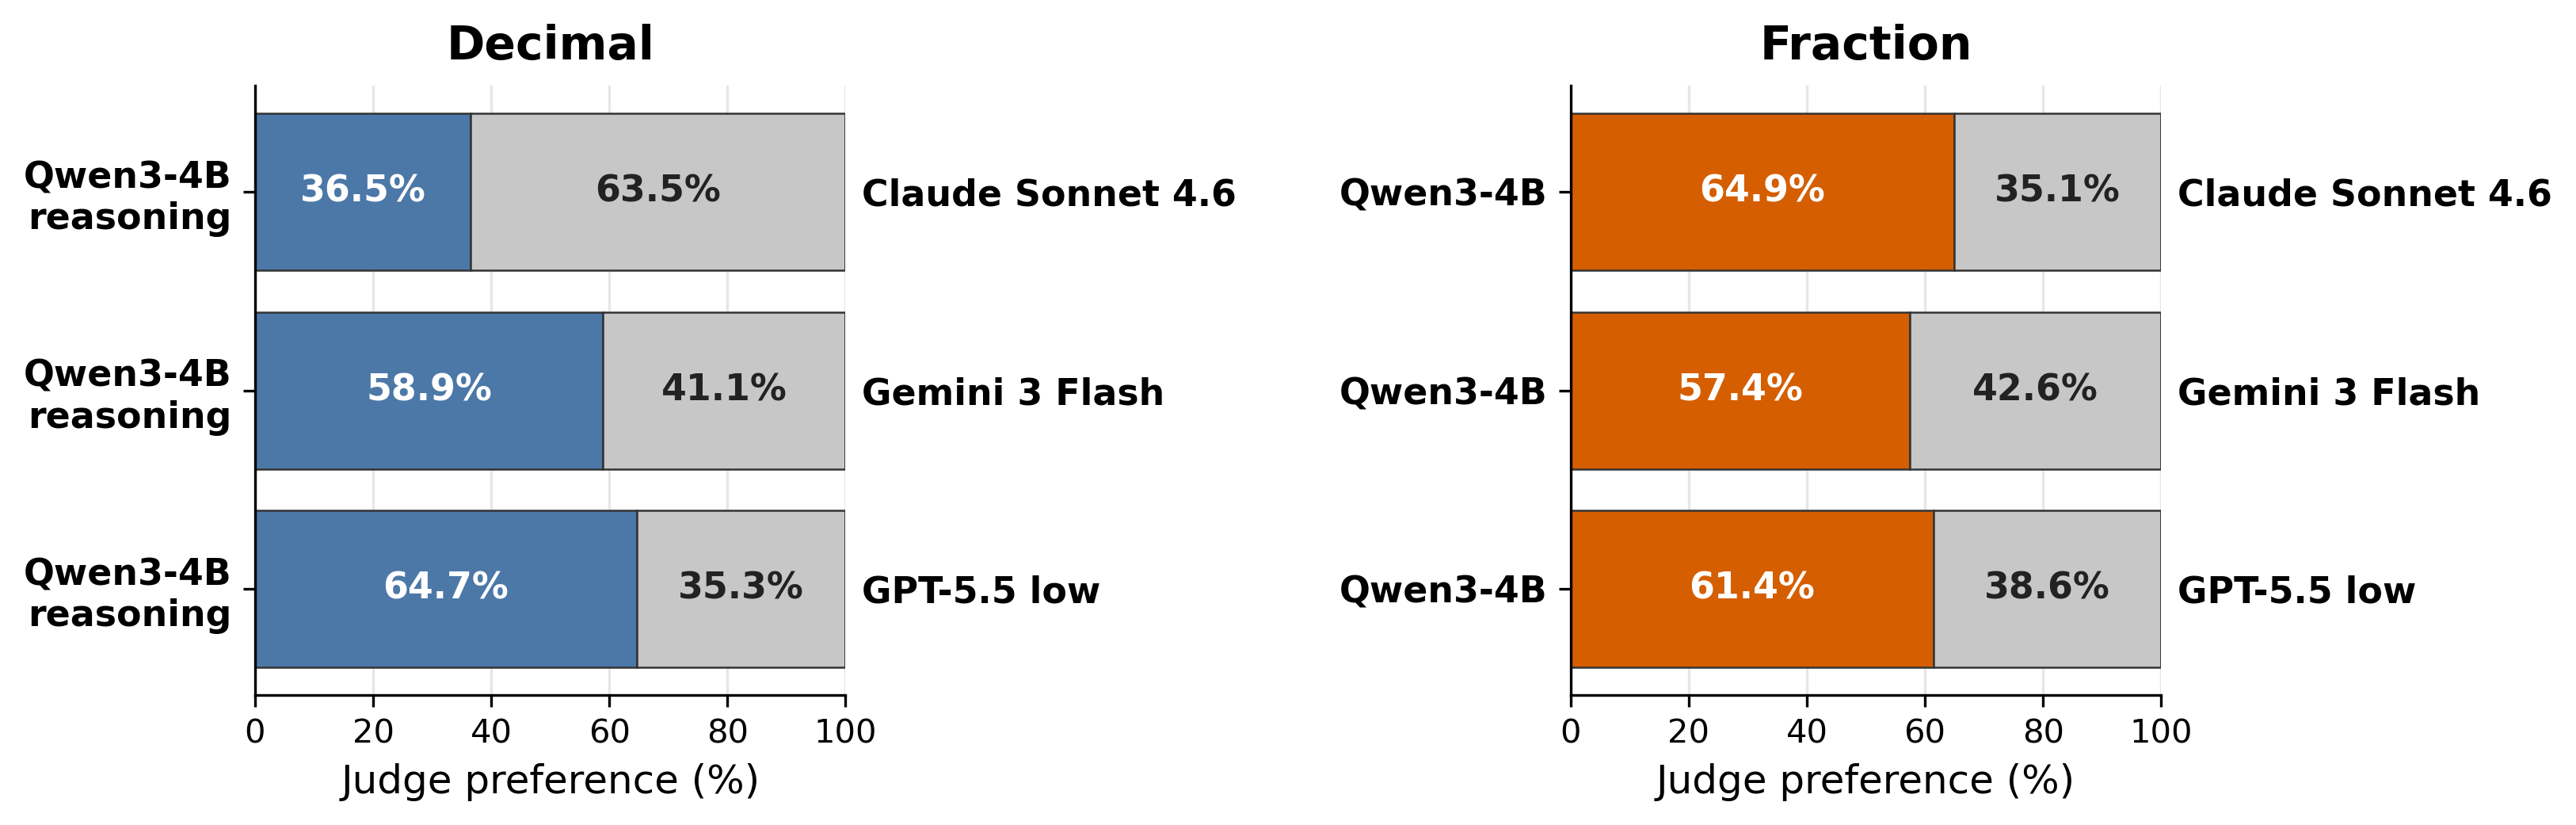

In [3]:
def annotate_rate(ax, left: float, width: float, y: float, text: str, color: str) -> None:
    if width >= 20:
        ax.text(
            left + width / 2,
            y,
            text,
            ha="center",
            va="center",
            color=color,
            fontsize=11,
            fontweight="bold",
        )
    else:
        x = min(left + width + 1.3, 97.5)
        ax.text(x, y, text, ha="left", va="center", color="#222222", fontsize=9.5)


def plot_domain_bars(ax, domain: str) -> None:
    data = summary[summary["domain"] == domain].copy()
    meta = DOMAIN_META[domain]
    y = np.arange(len(data)) * 0.86
    ax.barh(y, data["qwen_pct"], height=0.68, color=meta["color"], edgecolor=EDGE_COLOR, linewidth=0.6)
    ax.barh(
        y,
        data["baseline_pct"],
        left=data["qwen_pct"],
        height=0.68,
        color=MODEL_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=0.6,
    )
    ax.barh(
        y,
        data["tie_pct"],
        left=data["qwen_pct"] + data["baseline_pct"],
        height=0.68,
        color=TIE_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=0.6,
    )
    for yy, (_, row) in zip(y, data.iterrows()):
        annotate_rate(ax, 0.0, row["qwen_pct"], yy, f"{row['qwen_pct']:.1f}%", "white")
        annotate_rate(ax, row["qwen_pct"], row["baseline_pct"], yy, f"{row['baseline_pct']:.1f}%", "#222222")

    ax.set_yticks(y)
    ax.set_yticklabels([meta["anchor_label"]] * len(data), fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Judge preference (%)")
    ax.set_title(meta["title"], pad=8)
    ax.grid(axis="x", color="#E6E6E6", linewidth=0.8)
    ax.set_axisbelow(True)

    right_ax = ax.twinx()
    right_ax.set_ylim(ax.get_ylim())
    right_ax.set_yticks(y)
    right_ax.set_yticklabels(data["baseline_label"].tolist(), fontweight="bold")
    right_ax.tick_params(axis="y", length=0, pad=5)
    for spine in right_ax.spines.values():
        spine.set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.35), sharex=True, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.04, wspace=0.08, hspace=0.02)
plot_domain_bars(axes[0], "decimal")
plot_domain_bars(axes[1], "fraction")
bar_png = FIG_DIR / "qwen_frontier3_4b_humanlike_preference_bars.png"
bar_pdf = FIG_DIR / "qwen_frontier3_4b_humanlike_preference_bars.pdf"
fig.savefig(bar_png, bbox_inches="tight")
fig.savefig(bar_pdf, bbox_inches="tight")
plt.show()
print(bar_png)
print(bar_pdf)
display(Image(filename=str(bar_png)))

## Per-Problem Preference Heatmap

/scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures/qwen_frontier3_4b_humanlike_preference_by_problem.png
/scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures/qwen_frontier3_4b_humanlike_preference_by_problem.pdf


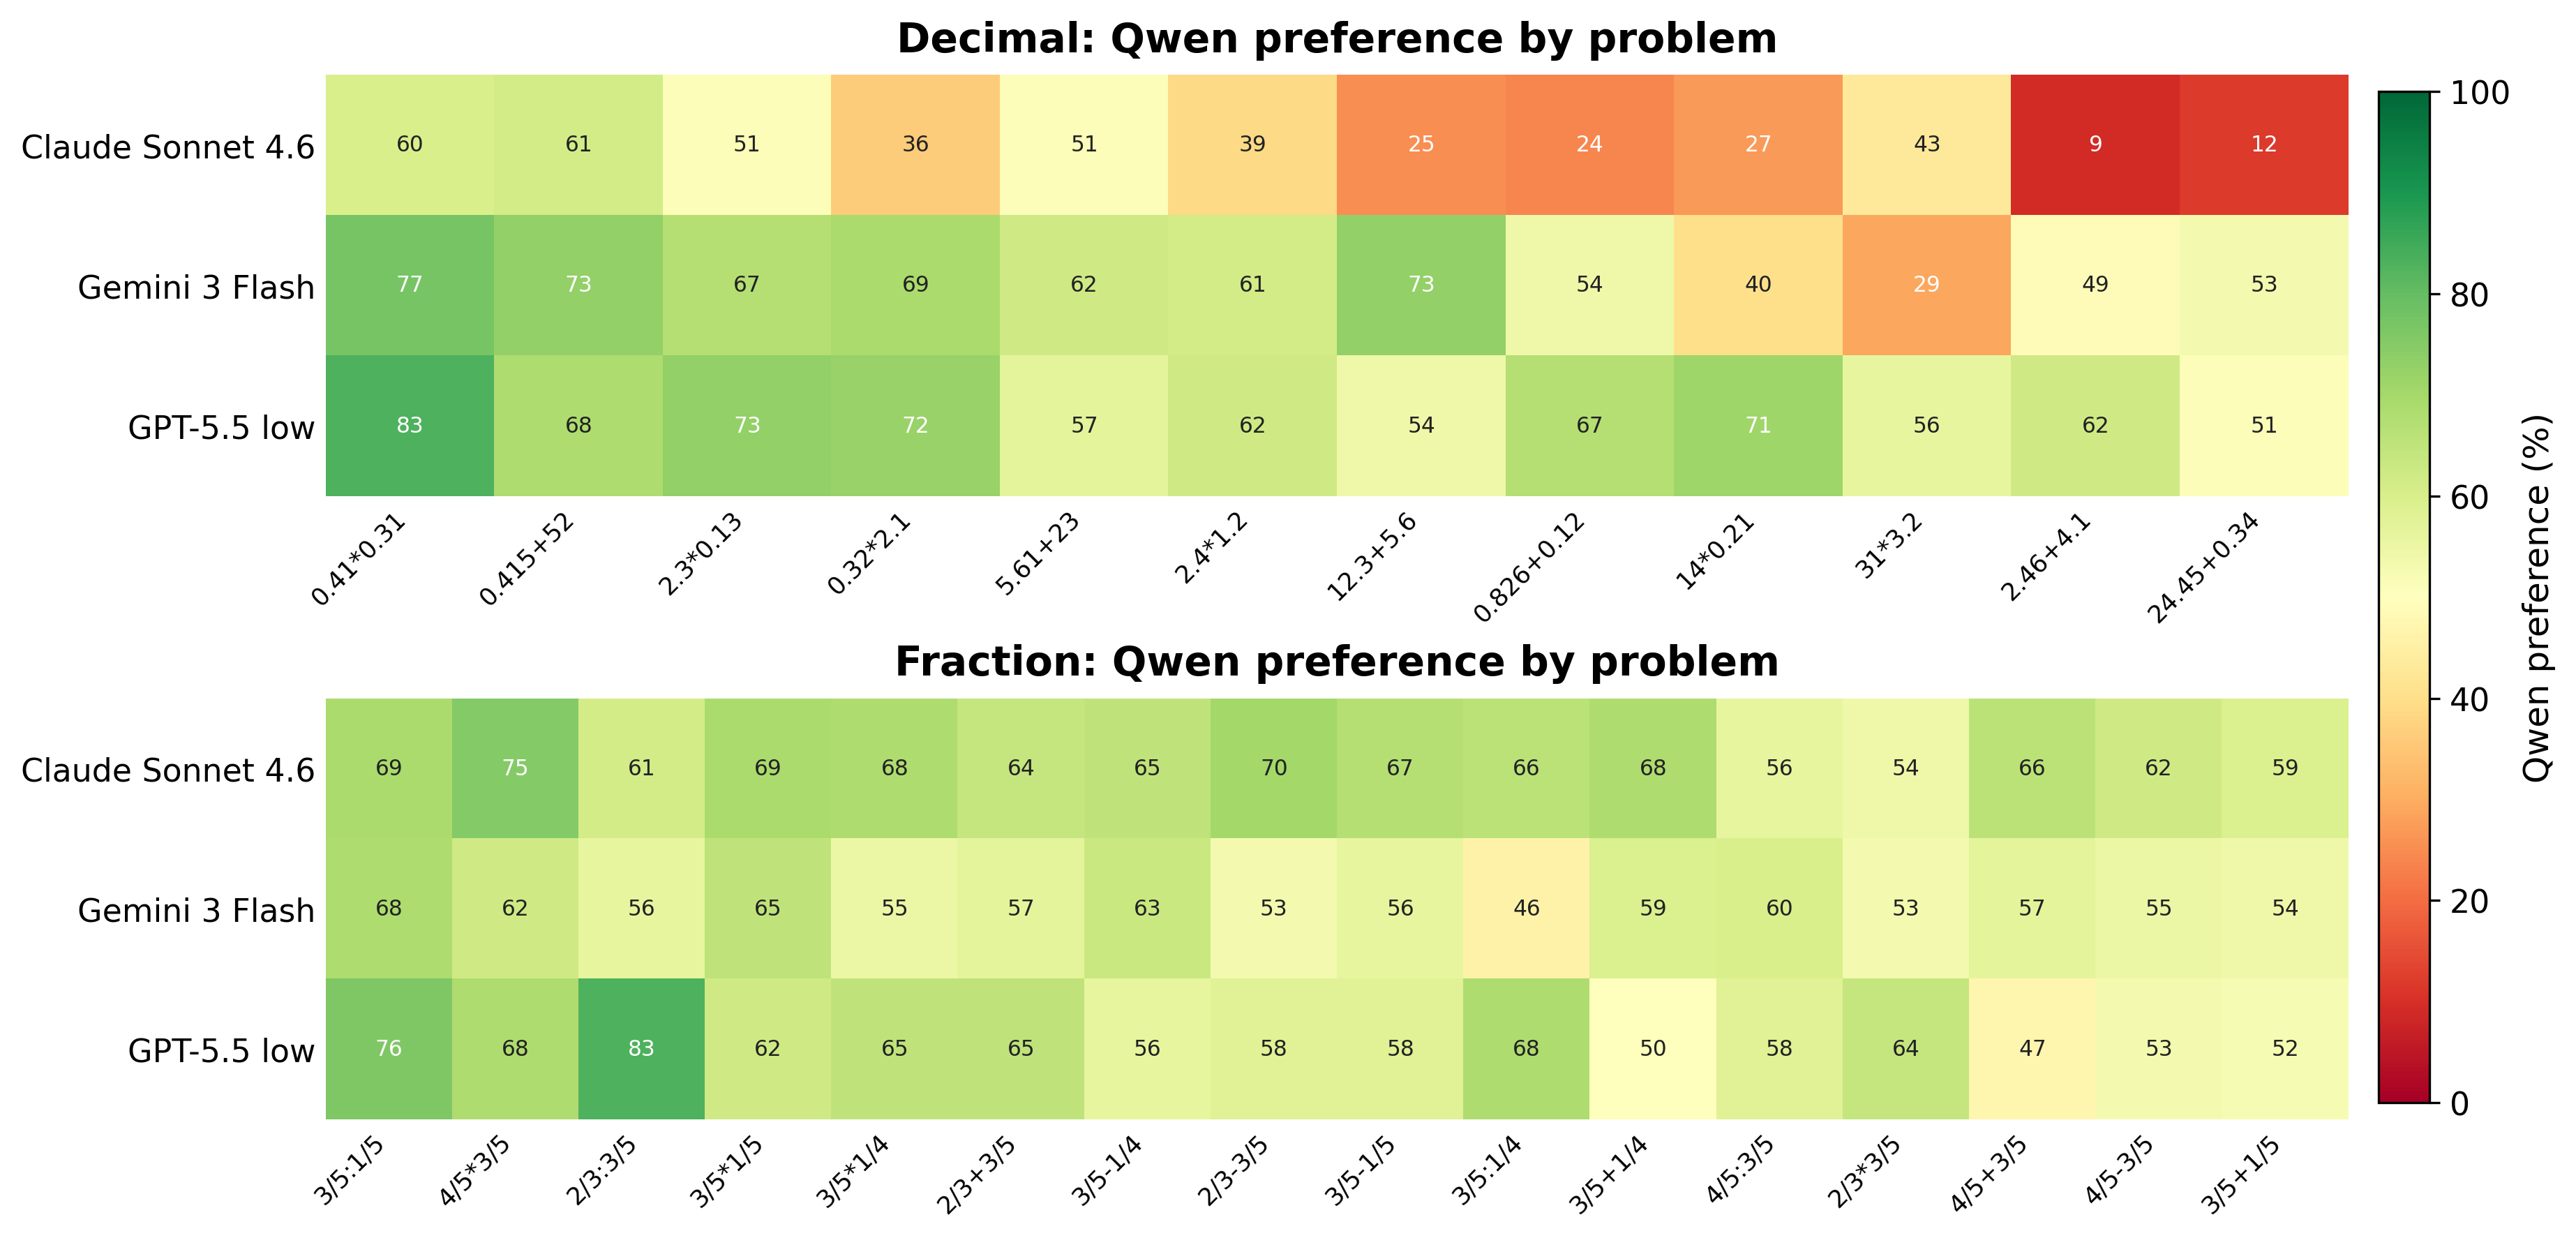

In [4]:
def ordered_problem_labels(domain: str) -> list[str]:
    data = by_problem[by_problem["domain"] == domain]
    means = data.groupby("prob", sort=False)["qwen_pct"].mean().sort_values(ascending=False)
    return means.index.tolist()


def plot_problem_heatmap(ax, domain: str) -> None:
    data = by_problem[by_problem["domain"] == domain].copy()
    problem_order = ordered_problem_labels(domain)
    matrix = data.pivot(index="baseline_label", columns="prob", values="qwen_pct")
    matrix = matrix.loc[[LABELS[name] for name in MODEL_ORDER], problem_order]

    image = ax.imshow(matrix.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_title(f"{DOMAIN_META[domain]['title']}: Qwen preference by problem", pad=8)
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right", fontsize=8.5)
    ax.tick_params(axis="both", length=0)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = matrix.iloc[row, col]
            text_color = "white" if value < 30 or value > 70 else "#222222"
            ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=7.5, color=text_color)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return image


fig, axes = plt.subplots(2, 1, figsize=(12.2, 5.8), constrained_layout=True)
image = plot_problem_heatmap(axes[0], "decimal")
plot_problem_heatmap(axes[1], "fraction")
cbar = fig.colorbar(image, ax=axes, fraction=0.025, pad=0.015)
cbar.set_label("Qwen preference (%)")

heatmap_png = FIG_DIR / "qwen_frontier3_4b_humanlike_preference_by_problem.png"
heatmap_pdf = FIG_DIR / "qwen_frontier3_4b_humanlike_preference_by_problem.pdf"
fig.savefig(heatmap_png, bbox_inches="tight")
fig.savefig(heatmap_pdf, bbox_inches="tight")
plt.show()
print(heatmap_png)
print(heatmap_pdf)
display(Image(filename=str(heatmap_png)))

## Plot Data Exports

In [5]:
plot_summary = summary[
    [
        "domain",
        "qwen_entity",
        "baseline_entity",
        "rows",
        "parse_success_rate",
        "qwen_preference_rate",
        "baseline_preference_rate",
        "tie_rate",
        "qwen_pct",
        "baseline_pct",
        "tie_pct",
    ]
]
plot_by_problem = by_problem[
    [
        "domain",
        "qwen_entity",
        "baseline_entity",
        "prob",
        "rows",
        "parse_success_rate",
        "qwen_preference_rate",
        "baseline_preference_rate",
        "tie_rate",
        "qwen_pct",
        "baseline_pct",
        "tie_pct",
    ]
]

summary_out = FIG_DIR / "qwen_frontier3_4b_humanlike_preference_plot_summary.csv"
problem_out = FIG_DIR / "qwen_frontier3_4b_humanlike_preference_plot_by_problem.csv"
plot_summary.to_csv(summary_out, index=False)
plot_by_problem.to_csv(problem_out, index=False)

display(plot_summary.round({"qwen_pct": 1, "baseline_pct": 1, "tie_pct": 1}))
print(summary_out)
print(problem_out)

,domain,qwen_entity,baseline_entity,rows,parse_success_rate,qwen_preference_rate,baseline_preference_rate,tie_rate,qwen_pct,baseline_pct,tie_pct
0,decimal,qwen3_4b_distill_humanft_reasoning,claude_sonnet_4_6,1200,1.0,0.365000,0.635000,0.0,36.5,63.5,0.0
1,decimal,qwen3_4b_distill_humanft_reasoning,gemini_3_flash,1200,1.0,0.589167,0.410833,0.0,58.9,41.1,0.0
2,decimal,qwen3_4b_distill_humanft_reasoning,gpt_5_5_low,1200,1.0,0.646667,0.353333,0.0,64.7,35.3,0.0
3,fraction,qwen3_4b_distill_humanft,claude_sonnet_4_6,1600,1.0,0.649375,0.350625,0.0,64.9,35.1,0.0
4,fraction,qwen3_4b_distill_humanft,gemini_3_flash,1600,1.0,0.574375,0.425625,0.0,57.4,42.6,0.0
5,fraction,qwen3_4b_distill_humanft,gpt_5_5_low,1600,1.0,0.614375,0.385625,0.0,61.4,38.6,0.0


/scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures/qwen_frontier3_4b_humanlike_preference_plot_summary.csv
/scratch/gpfs/BRENDEN/changho/UMA_PR02_main_max_share/eval/results/humanlike_preference/qwen_frontier3_4b_gemini31_flash_lite/figures/qwen_frontier3_4b_humanlike_preference_plot_by_problem.csv
